In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.datasets import load_diabetes, load_iris, load_wine
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from typing import List, Optional, Tuple, Union
from xgboost import XGBClassifier, XGBRegressor

In [21]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


In [22]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader_simple import load_and_preprocess

df = load_and_preprocess(PROJECT_ROOT / "data" / "raw" / "dataset_practica_final.csv")
X = df.drop(columns="is_canceled")
y = df["is_canceled"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento de un modelo de RandomForest Classifier
modelo_rfc = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42)
modelo_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=500, random_state=42)

In [24]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_rfc.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.81
Precisión: 0.90
Recall:    0.55
F1-Score:  0.68
AUC:       0.88



In [25]:
modelo_rfc.feature_importances_

array([1.08593909e-01, 8.00658739e-03, 3.83733681e-03, 2.05530866e-03,
       1.93642661e-03, 5.30834201e-03, 3.92447144e-03, 5.28510284e-04,
       3.82918831e-05, 2.58924668e-03, 9.55389931e-02, 7.67427626e-03,
       3.46060592e-02, 6.04677336e-03, 1.59804406e-02, 4.42928581e-02,
       9.46749567e-02, 5.69761045e-03, 5.03758384e-03, 4.06076042e-03,
       9.50146442e-03, 8.29034141e-03, 9.13281637e-05, 2.04556114e-03,
       1.69441743e-02, 5.30581606e-02, 1.34633242e-02, 3.48941749e-02,
       9.57228737e-05, 4.09071582e-02, 3.11955341e-02, 1.50895542e-04,
       8.95812839e-05, 7.00629276e-04, 1.87430567e-04, 4.33547782e-05,
       1.22075493e-04, 2.96132684e-05, 9.06018212e-06, 2.28996072e-03,
       2.48690472e-03, 9.28857961e-03, 8.76531076e-03, 8.38503178e-04,
       9.71044247e-04, 6.16259162e-04, 1.39474531e-04, 3.12275715e-01,
       7.99206197e-05])

In [26]:
# Importancia de variables
col_importancia_rf = modelo_rfc.feature_importances_

df_importances_rf = pd.DataFrame({
    'variable' : X.columns,
    'importancia' : col_importancia_rf
})

In [27]:
df_importances_rf.sort_values(by=['importancia'], ascending=False)

,variable,importancia
47,deposit_type_Non Refund,0.312276
0,lead_time,0.108594
10,previous_cancellations,0.095539
16,total_of_special_requests,0.094675
25,market_segment_Groups,0.053058
15,required_car_parking_spaces,0.044293
29,customer_type_Transient,0.040907
27,market_segment_Online TA,0.034894
12,booking_changes,0.034606
30,customer_type_Transient-Party,0.031196


In [28]:
df_importances_rf = df_importances_rf.sort_values(by='importancia', ascending=True)

In [29]:
# Visualización de la importancia de las variables
fig = px.bar(
    df_importances_rf,
    x='importancia',
    y='variable',
    text='importancia',
    text_auto=".3%",
    title='Importancia de las variables en el modelo Random Forest',
    labels={'x': 'Importancia', 'y': 'Variable'},
    width=700, height=500
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [30]:
df = load_and_preprocess(PROJECT_ROOT / "data" / "raw" / "dataset_practica_final.csv")
X_withdeposit = df.drop(columns="is_canceled")
X = X_withdeposit.drop(columns=[c for c in df.columns if c.startswith("deposit_type_")])
y = df["is_canceled"]


In [31]:
# Preparación de los datos para el entrenamiento del modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento de un modelo de RandomForest Classifier
modelo_rfc = RandomForestClassifier(n_estimators=500, max_depth=20, random_state=42)
modelo_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=500, random_state=42)

In [32]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_rfc.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.85
Precisión: 0.87
Recall:    0.72
F1-Score:  0.78
AUC:       0.93



In [33]:
# Importancia de variables
col_importancia_rf = modelo_rfc.feature_importances_

df_importances_rf = pd.DataFrame({
    'variable' : X.columns,
    'importancia' : col_importancia_rf
})

In [34]:
df_importances_rf.sort_values(by=['importancia'], ascending=False)

,variable,importancia
0,lead_time,0.144139
16,total_of_special_requests,0.096732
10,previous_cancellations,0.068842
14,adr,0.055239
42,adr_per_night,0.053044
41,adr_per_person,0.052333
25,market_segment_Groups,0.050166
29,customer_type_Transient,0.037781
2,arrival_date_week_number,0.036844
3,arrival_date_day_of_month,0.035327


In [35]:
df_importances_rf = df_importances_rf.sort_values(by='importancia', ascending=True)

In [36]:
# Visualización de la importancia de las variables
fig = px.bar(
    df_importances_rf,
    x='importancia',
    y='variable',
    text='importancia',
    text_auto=".3%",
    title='Importancia de las variables en el modelo Random Forest',
    labels={'x': 'Importancia', 'y': 'Variable'},
    width=700, height=500
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

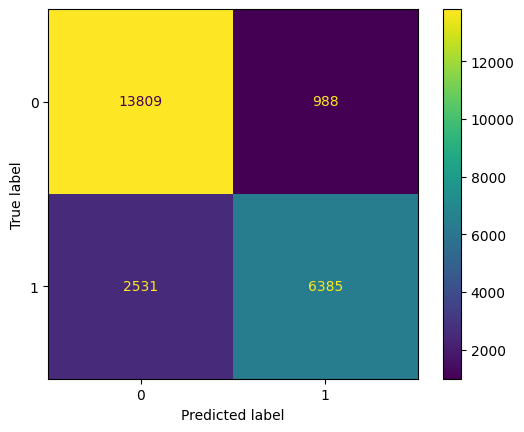

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

y_pred = modelo_rfc.predict(X_test)
y_proba = modelo_rfc.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

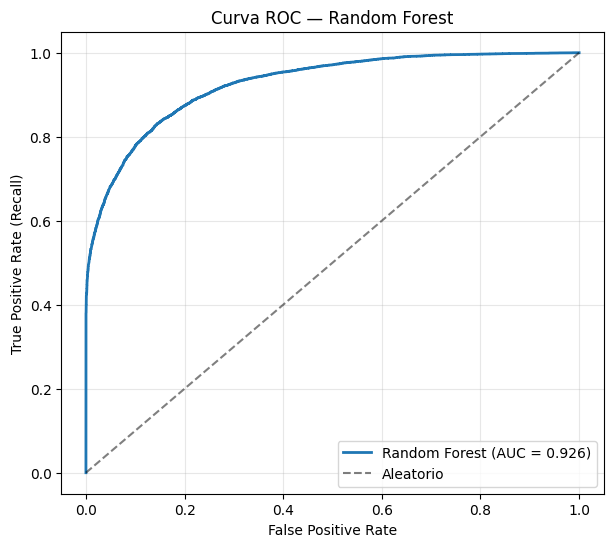

In [38]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Aleatorio", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Curva ROC — Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

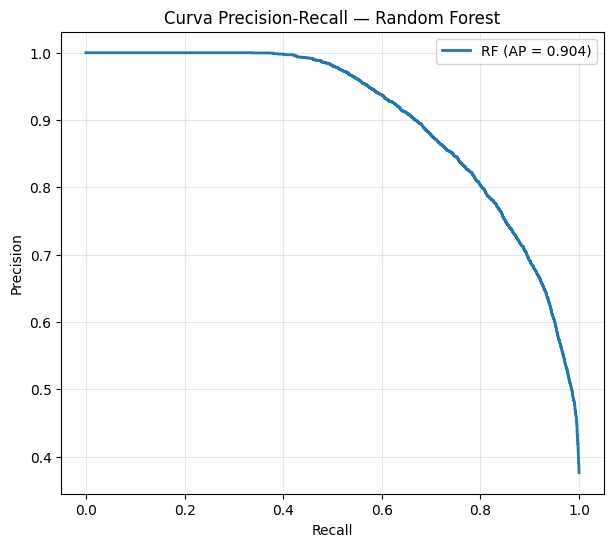

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, thr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, label=f"RF (AP = {ap:.3f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
from sklearn.metrics import f1_score

f1_scores = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1_scores))
print(f"Umbral óptimo para F1: {thresholds[best_idx]:.3f}")
print(f"F1 en ese umbral: {f1_scores[best_idx]:.3f}")
print(f"F1 en umbral 0.5: {f1:.3f}")

Umbral óptimo para F1: 0.362
F1 en ese umbral: 0.803
F1 en umbral 0.5: 0.784


In [41]:
df = load_and_preprocess(PROJECT_ROOT / "data" / "raw" / "dataset_practica_final.csv")
X_withdeposit = df.drop(columns="is_canceled")
X = X_withdeposit.drop(columns=[c for c in df.columns if c.startswith("deposit_type_")])
y = df["is_canceled"]

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": [None, "balanced"],
}

rf = RandomForestClassifier(random_state=42, n_jobs=1)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                # 30 combinaciones aleatorias
    cv=5,
    scoring="f1",             # consistente con tu criterio principal
    n_jobs=2,
    random_state=42,
    verbose=1,
)

search.fit(X_train, y_train)   # ← versión sin deposit_type

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor F1 (CV): {search.best_score_:.3f}")

best_rf = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced'}
Mejor F1 (CV): 0.805


In [43]:
# Evaluación del mejor modelo en test
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

acc_best  = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best  = recall_score(y_test, y_pred_best)
f1_best   = f1_score(y_test, y_pred_best)
auc_best  = roc_auc_score(y_test, y_proba_best)

print("=== RF tuneado (RandomizedSearchCV) ===")
print(f"Accuracy:  {acc_best:.3f}")
print(f"Precisión: {prec_best:.3f}")
print(f"Recall:    {rec_best:.3f}")
print(f"F1-Score:  {f1_best:.3f}")
print(f"AUC:       {auc_best:.3f}")

=== RF tuneado (RandomizedSearchCV) ===
Accuracy:  0.862
Precisión: 0.841
Recall:    0.780
F1-Score:  0.809
AUC:       0.930


In [44]:
import joblib
joblib.dump(best_rf, PROJECT_ROOT / "models" / "rf_best_tuned.joblib")
print("Guardado en models/rf_best_tuned.joblib")

Guardado en models/rf_best_tuned.joblib


In [45]:
from sklearn.metrics import f1_score, precision_recall_curve

precision_vals, recall_vals, thresholds_best = precision_recall_curve(y_test, y_proba_best)
f1s = [f1_score(y_test, (y_proba_best >= t).astype(int)) for t in thresholds_best]
best_idx = int(np.argmax(f1s))

print(f"Umbral óptimo: {thresholds_best[best_idx]:.3f}")
print(f"F1 en ese umbral: {f1s[best_idx]:.3f}")
print(f"F1 en umbral 0.5: {f1_best:.3f}")

Umbral óptimo: 0.449
F1 en ese umbral: 0.811
F1 en umbral 0.5: 0.809


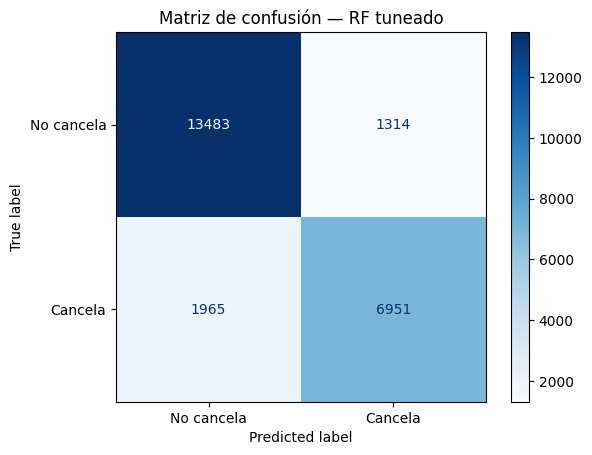

FN (cancelaciones perdidas): 1965 (22.0% de las reales)
FP (falsas alarmas): 1314


In [46]:
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm_best, display_labels=["No cancela", "Cancela"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión — RF tuneado")
plt.show()

tn, fp, fn, tp = cm_best.ravel()
print(f"FN (cancelaciones perdidas): {fn} ({fn/(fn+tp):.1%} de las reales)")
print(f"FP (falsas alarmas): {fp}")